In [1]:
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784')

In [3]:
x, y = mnist['data'], mnist['target']

In [4]:
x.shape

(70000, 784)

In [5]:
y.shape

(70000,)

In [6]:
%matplotlib inline

In [7]:
import matplotlib
import matplotlib.pyplot as plt

In [8]:
some_digit = x.iloc[36001].values          
some_digit_image = some_digit.reshape(28, 28) 

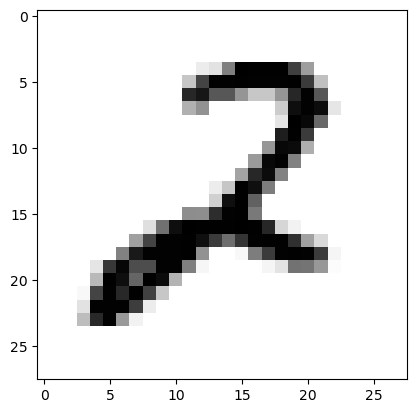

In [9]:
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')


In [10]:
y[36001]

'2'

In [11]:
x_train, x_test = x[:6000], x[6000:]

In [12]:
y_train, y_test = y[:6000], y[6000:]

In [13]:
import numpy as np
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

In [14]:
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train==2)
y_test_2 = (y_test==2)

In [15]:
y_test_2

6000     False
6001     False
6002     False
6003     False
6004     False
         ...  
69995     True
69996    False
69997    False
69998    False
69999    False
Name: class, Length: 64000, dtype: bool

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
clf = LogisticRegression(tol = 0.1)

In [18]:
clf.fit(x_train.values, y_train_2)

,penalty,'l2'
,dual,False
,tol,0.1
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
clf.predict([some_digit])

array([ True])

In [20]:
from sklearn.model_selection import cross_val_score
a = cross_val_score(clf, x_train, y_train_2, cv=3, scoring="accuracy")

In [21]:
a.mean()

np.float64(0.9543333333333334)